# Data Exploration of Relationship Between Unanet and CIPs

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [182]:
with open('../data/cip.json', 'r') as f:
    dict = json.load(f)
    cip = pd.DataFrame(dict.get("records"))

unanet = pd.read_csv('../data/unanet.csv')

In [183]:
cip.head(5)

,ID Number,Project,Ag. Proj. #,Market,Description,Type,Agency,Year,Professional Services Budget,Overall Budget,Contact,Phone,Email,Revised
0,94277,Ute and McNeill Field Complex,,Colorado,"As we reported previously, the District expect...","AS, DR, MS, PK, ST",Montrose Recreation District,2027,$,"$ 600,000",Jeremy Master,970-497-8569,,06/01/26
1,94446,East Bookend of Civic Area Redev.,,Colorado,"As we reported previously, the City released a...","AS, MS, PL",Boulder,2026,$,$,Shihomi Kuriyagawa,303-413-7233,kuriyagawas@bouldercolorado.gov,06/01/26
2,94452,Marshal's Office Addition/Renovation,,Colorado,"As we reported previously, the Town plans to a...","AS, CM",Crested Butte,2026,$,$,Connor Beard,"970-3349-5338, x122",cbeard@crestedbutte-co.gov,06/01/26
3,94792,Property Inventory and Prel. Site Analysis,,Colorado,"As we reported previously, the Town plans to s...","AS, MS, PL",Wellington,2026,$,$,Cody Bird,,birdca@wellingtoncolorado.gov,06/01/26
4,94793,Policy Review and Rec's for Infill Housing,,Colorado,"As we reported previously, the Town plans to a...","AS, PL",Wellington,2026,$,$,Cody Bird,,birdca@wellingtoncolorado.gov,06/01/26


In [184]:
unanet.head(5)

,Lead Name,Stage,Status,Score,City,State,Notes,Next Action,Client,Created By,...,Secondary Categories,Divisions,Studios,Client Type,Office Division,Lead Source,Estimated Size,Estimated Unit Size,Solicitation Number,NAICS Code(s)
0,Evans Freedom Gateway,Unassigned,Open,(1) Unlikely,Loveland,Colorado,NaN,Start proposal for this - February/March Kick-...,NaN,Joe Berlin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dillon Amphitheater Restroom Remodel,Assigned,Open,(3) Likely,Dillon,Colorado,NaN,Putting together a proposal for Ryan,JHL Constructors,Jordan Lockner,...,Bathrooms,NaN,NaN,Public,NaN,NaN,NaN,NaN,NaN,NaN
2,Weld County Administration,Unassigned,Open,(2) Meh,Greeley,Colorado,Need to create renderings and set up a meeting...,Riley Johnson providing schematics - Jeff to s...,Weld County,Jordan Lockner,...,NaN,NaN,NaN,Public,NaN,NaN,425000.0,NaN,NaN,NaN
3,Bond Election - Montrose CO School District _ ...,Unassigned,Open,(1) Unlikely,Montrose,Colorado,Note: Review November ballot results when tick...,Follow Up with Riley at Dynamic to make introd...,NaN,Erica Sayers,...,Classrooms Food Service Entry Vestibule Securi...,NaN,NaN,NaN,NaN,CIP,NaN,NaN,CIP ID # 93649,NaN
4,Denver TF - 16th Street retail,Unassigned,Open,(2) Meh,Denver,Colorado,NaN,Jordan followed up week of 12/20 - not update,NaN,Jordan Lockner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [185]:
print('Number of Rows CIP:', len(cip))
print('Number of Rows Unanet:', len(unanet))

Number of Rows CIP: 4150
Number of Rows Unanet: 50


In [186]:
unanet['Solicitation Number']

0                NaN
1                NaN
2                NaN
3     CIP ID # 93649
4                NaN
5     CIP ID # 93411
6                NaN
7                NaN
8                NaN
9                NaN
10               NaN
11               NaN
12               NaN
13               NaN
14      CIP ID#93828
15               NaN
16               NaN
17      CIP ID#72468
18     CIP ID# 74586
19     CIP ID# 81822
20     CIP ID# 83887
21     CIP ID# 88748
22     CIP ID# 89096
23     CIP ID# 90563
24     CIP ID# 91365
25     CIP ID# 91415
26     CIP ID# 91734
27     CIP ID# 92129
28     CIP ID# 92347
29     CIP ID# 92942
30     CIP ID# 93132
31     CIP ID# 93151
32     CIP ID# 93531
33     CIP ID# 93769
34     CIP ID# 93786
35     CIP ID# 93830
36     CIP ID# 93850
37     CIP ID# 93855
38     CIP ID# 93856
39     CIP ID# 93860
40     CIP ID# 93865
41     CIP ID# 93892
42     CIP ID# 93907
43     CIP ID# 93909
44     CIP ID# 93924
45     CIP ID# 93925
46     CIP ID# 93939
47      CIP I

In [187]:
unanet['Solicitation Number'].isna().value_counts()

Solicitation Number
False    35
True     15
Name: count, dtype: int64

In [188]:
import re

unanet['CIP ID'] = unanet['Solicitation Number'].str.extract(r'(\d+)')

In [189]:
unanet.head(5)

,Lead Name,Stage,Status,Score,City,State,Notes,Next Action,Client,Created By,...,Divisions,Studios,Client Type,Office Division,Lead Source,Estimated Size,Estimated Unit Size,Solicitation Number,NAICS Code(s),CIP ID
0,Evans Freedom Gateway,Unassigned,Open,(1) Unlikely,Loveland,Colorado,NaN,Start proposal for this - February/March Kick-...,NaN,Joe Berlin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dillon Amphitheater Restroom Remodel,Assigned,Open,(3) Likely,Dillon,Colorado,NaN,Putting together a proposal for Ryan,JHL Constructors,Jordan Lockner,...,NaN,NaN,Public,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Weld County Administration,Unassigned,Open,(2) Meh,Greeley,Colorado,Need to create renderings and set up a meeting...,Riley Johnson providing schematics - Jeff to s...,Weld County,Jordan Lockner,...,NaN,NaN,Public,NaN,NaN,425000.0,NaN,NaN,NaN,NaN
3,Bond Election - Montrose CO School District _ ...,Unassigned,Open,(1) Unlikely,Montrose,Colorado,Note: Review November ballot results when tick...,Follow Up with Riley at Dynamic to make introd...,NaN,Erica Sayers,...,NaN,NaN,NaN,NaN,CIP,NaN,NaN,CIP ID # 93649,NaN,93649
4,Denver TF - 16th Street retail,Unassigned,Open,(2) Meh,Denver,Colorado,NaN,Jordan followed up week of 12/20 - not update,NaN,Jordan Lockner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [190]:
df = pd.merge(unanet, cip, left_on = 'CIP ID', right_on = 'ID Number', how='inner')

In [191]:
df.head(5)

,Lead Name,Stage,Status,Score,City,State,Notes,Next Action,Client,Created By,...,Description,Type,Agency,Year,Professional Services Budget,Overall Budget,Contact_y,Phone_y,Email_y,Revised
0,Bond Election - Montrose CO School District _ ...,Unassigned,Open,(1) Unlikely,Montrose,Colorado,Note: Review November ballot results when tick...,Follow Up with Riley at Dynamic to make introd...,NaN,Erica Sayers,...,We reported previously that the District would...,"AS, GI",Montrose Co. School Dist. RE-1J,2024,$,"$ 198,000,000",Micah Adams,,micah.adams@dynamicpm.com,12/02/24
1,Town of Timnath Recreation Center,Unassigned,Open,(2) Meh,Timnath,Colorado,Setting up coffee with Tom Jordan's Notes (F...,NaN,Town of Timnath,Erica Sayers,...,"The Town has allocated $50,000 in 2025 for pla...","AS, MS",Timnath,Unknown,"$ 4,500,000","$ 74,500,000",,,,01/29/25
2,Longmont Recreation Center Fitness Improvements,Unassigned,Open,(2) Meh,Longmont,Colorado,No Contact info Jordan's Notes: \tUnfunded ...,NaN,City of Longmont,Erica Sayers,...,This unfunded project provides for redesign of...,"AS, MS",Longmont,Unknown,$,"$ 1,940,206",,,,01/28/26
3,Alta Park Master Planned Improvements,Unassigned,Open,(2) Meh,Longmont,Colorado,Jordan's Notes: Potential Partners: Design Con...,NaN,City of Longmont,Erica Sayers,...,The project includes completion of master plan...,"AS, PK, WR",Longmont,2027,$,"$ 2,445,846",,,,01/29/25
4,Sunset Campus Expansion,Unassigned,Open,(2) Meh,Longmont,Colorado,Jordan's Notes: Need to Pre-Position CIP Desc...,NaN,City of Longmont,Erica Sayers,...,The City proposes to design and build out the ...,"AS, MS, PK, ST",Longmont,Unknown,$,"$ 2,836,471",,,,01/28/26


In [192]:
df.columns

Index(['Lead Name', 'Stage', 'Status', 'Score', 'City', 'State', 'Notes',
       'Next Action', 'Client', 'Created By', 'Assigned To', 'Market Sector',
       'Offices', 'Service Types', 'Record Source', 'Marketing Campaign',
       'Create Date', 'Month Created', 'Origination Date', 'Bid Date',
       'Tickler Date', 'Sub Categories', 'Est. Cost', 'Lead Age (days)',
       'Lead Days in System', 'Conversion to Opp Hours',
       'Conversion to Opp Days', 'Email_x', 'Conversion Status',
       'Last Modified Date', 'Last Event', 'Risk Profile', 'Deliverables',
       'Comments', 'Contact_x', 'Phone_x', 'Contract Type', 'Form URL',
       'Primary Categories', 'Secondary Categories', 'Divisions', 'Studios',
       'Client Type', 'Office Division', 'Lead Source', 'Estimated Size',
       'Estimated Unit Size', 'Solicitation Number', 'NAICS Code(s)', 'CIP ID',
       'ID Number', 'Project', 'Ag. Proj. #', 'Market', 'Description', 'Type',
       'Agency', 'Year', 'Professional Services Bud

In [193]:
df['Type']

0                         AS, GI
1                         AS, MS
2                         AS, MS
3                     AS, PK, WR
4                 AS, MS, PK, ST
5                         AS, MS
6             AS, DR, MS, PK, ST
7             AS, DR, MS, PK, ST
8                     AS, MS, PK
9                     AS, MS, PK
10                        AS, MS
11                        AS, MS
12                        AS, MS
13                        AS, MS
14                        AS, MS
15                        AS, MS
16    AS, DR, MS, PK, SW, ST, WR
17                        AS, MS
18                        AS, MS
19                        AS, MS
20                        AS, MS
21                        AS, MS
22                        AS, MS
23                        AS, PL
24                    AS, EV, MS
25            AS, DR, MS, PK, ST
26                        AS, MS
27                        AS, MS
28                        AS, MS
29                        AS, MS
30        

In [223]:
df['Type'].str.replace(" ", "").str.split(',')

0                         [AS, GI]
1                         [AS, MS]
2                         [AS, MS]
3                     [AS, PK, WR]
4                 [AS, MS, PK, ST]
5                         [AS, MS]
6             [AS, DR, MS, PK, ST]
7             [AS, DR, MS, PK, ST]
8                     [AS, MS, PK]
9                     [AS, MS, PK]
10                        [AS, MS]
11                        [AS, MS]
12                        [AS, MS]
13                        [AS, MS]
14                        [AS, MS]
15                        [AS, MS]
16    [AS, DR, MS, PK, SW, ST, WR]
17                        [AS, MS]
18                        [AS, MS]
19                        [AS, MS]
20                        [AS, MS]
21                        [AS, MS]
22                        [AS, MS]
23                        [AS, PL]
24                    [AS, EV, MS]
25            [AS, DR, MS, PK, ST]
26                        [AS, MS]
27                        [AS, MS]
28                  

In [194]:
df['City'].value_counts()

City
Longmont          8
Timnath           4
Littleton         3
Windsor           2
Canyon City       2
Avon              2
Montrose          1
Longmonth         1
Grand Junction    1
Broomfield        1
Lyons             1
Breckenridge      1
Westminster       1
Craig             1
Wellington        1
Name: count, dtype: int64

In [195]:
df['Overall Budget'] = df['Overall Budget'].str.extract(r'([\d,]+)')[0].str.replace(',','').astype("Int64")

In [196]:
df['Overall Budget']

0     198000000
1      74500000
2       1940206
3       2445846
4       2836471
5       4440000
6       4160000
7      21679754
8      12019600
9      23140000
10     13570000
11      6000000
12         9575
13      2500000
14      3132000
15       600000
16     18000000
17      4442096
18      1060520
19       350000
20      2000000
21      2954000
22     30000000
23       225000
24      1000000
25      3700000
26       750000
27       900000
28       350000
29         <NA>
30       700000
31       780000
32    607000000
33       300000
Name: Overall Budget, dtype: Int64

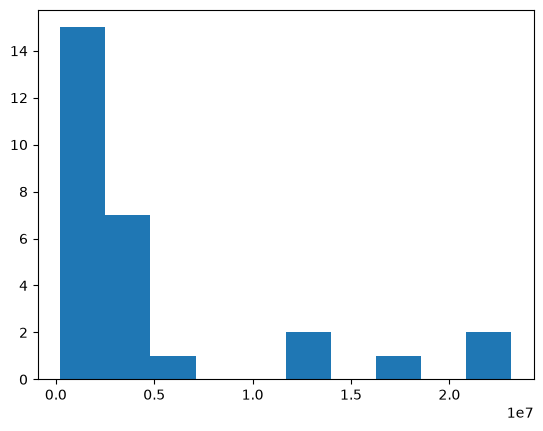

In [197]:
budget = df['Overall Budget'].copy().dropna()
lower, upper = budget.quantile([0.01, 0.9])
budget = budget[(budget >= lower) & (budget <= upper)]

plt.hist(budget)
plt.show()

In [202]:
df['Est. Cost'].value_counts()

Est. Cost
$300,000        2
$350,000        2
$700,000        2
$198,000,000    1
$2,742,990      1
$2,445,846      1
$2,836,741      1
$4,160,000      1
$21,679,754     1
$12,019,600     1
$23,140,000     1
$13,570,000     1
$6,000,000      1
$2,500,000      1
$2,900,000      1
$18,000,000     1
$4,442,096      1
$1,060,520      1
$2,000,000      1
$2,954,000      1
$30,000,000     1
$225,000        1
$1,000,000      1
$3,700,000      1
$750,000        1
$250,000        1
$780,000        1
$607,000,000    1
Name: count, dtype: int64